In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:

def skew(v):
    """Кососимметрическая матрица для вектора v ∈ R^3."""
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])

def quat_to_rot(q):
    """Преобразование кватерниона q=[w,x,y,z] в матрицу поворота 3x3."""
    w, x, y, z = q
    return np.array([
        [1 - 2*y**2 - 2*z**2, 2*x*y - 2*w*z, 2*x*z + 2*w*y],
        [2*x*y + 2*w*z, 1 - 2*x**2 - 2*z**2, 2*y*z - 2*w*x],
        [2*x*z - 2*w*y, 2*y*z + 2*w*x, 1 - 2*x**2 - 2*y**2]
    ])

def rotation_vector_to_quaternion(theta):
    """Преобразование вектора малых углов θ ∈ R^3 в кватернион."""
    norm = np.linalg.norm(theta)
    if norm < 1e-10:
        return np.array([1.0, 0.0, 0.0, 0.0])
    u = theta / norm
    return np.array([np.cos(norm / 2), 
                     u[0] * np.sin(norm / 2), 
                     u[1] * np.sin(norm / 2), 
                     u[2] * np.sin(norm / 2)])

def quat_multiply(q1, q2):
    """Умножение кватернионов: q_res = q1 ⊗ q2."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def normalize_quat(q):
    """Нормализация кватерниона."""
    return q / np.linalg.norm(q)

In [3]:
def compute_F_matrix(dt, q, acc):
    """
    Матрица перехода состояния F_{k-1}.
    δx_k = F_{k-1} δx_{k-1} + L_{k-1} n_{k-1}
    """
    R = quat_to_rot(q)
    F = np.eye(9)
    F[0:3, 3:6] = np.eye(3) * dt
    # -[R(q)*f]_x * dt
    F[3:6, 6:9] = -skew(R @ acc) * dt
    return F

def compute_process_noise(var_acc, var_gyro, dt):
    """Матрица ковариации процесса шума Q_k = L * Q_n * L^T."""
    # L матрица 9x6: [0 0; I 0; 0 I]
    L = np.zeros((9, 6))
    L[3:6, 0:3] = np.eye(3)
    L[6:9, 3:6] = np.eye(3)
    
    # Q_n = dt^2 * diag(σ_acc^2 I3, σ_gyro^2 I3)
    Q_n = (dt**2) * np.block([
        [var_acc * np.eye(3), np.zeros((3, 3))],
        [np.zeros((3, 3)), var_gyro * np.eye(3)]
    ])
    return L @ Q_n @ L.T

def kalman_update(P, dt, q, acc, p_nom, measurements, variances, var_acc, var_gyro):
    """
    Шаг коррекции ESKF для произвольного набора измерений (GNSS, LiDAR).
    Возвращает вектор ошибки md и обновлённую ковариацию P.
    """
    # 1. Прогноз ковариации
    F = compute_F_matrix(dt, q, acc)
    Q = compute_process_noise(var_acc, var_gyro, dt)
    P = F @ P @ F.T + Q

    n_meas = len(measurements)
    if n_meas == 0:
        return np.zeros(9), P

    # 2. Формируем общий вектор измерений и шум
    y_all = np.concatenate(measurements, axis=0)
    Q_all = np.zeros((3 * n_meas, 3 * n_meas))
    for i, var in enumerate(variances):
        Q_all[3*i : 3*(i+1), 3*i : 3*(i+1)] = var * np.eye(3)

    # 3. Матрица наблюдений H: для каждого измерения H = [I3 | 0 | 0]
    H_all = np.zeros((3 * n_meas, 9))
    for i in range(n_meas):
        H_all[3*i : 3*(i+1), 0:3] = np.eye(3)

    # 4. Инновация и ковариация инновации
    y_pred = np.tile(p_nom, n_meas)
    S = H_all @ P @ H_all.T + Q_all
    S += np.eye(3 * n_meas) * 1e-10  # Численная стабилизация
    
    # 5. Коэффициент усиления Калмана
    K = P @ H_all.T @ np.linalg.inv(S)
    
    # 6. Вектор ошибки состояния
    md = K @ (y_all - y_pred)
    
    # 7. Обновление ковариации (форма Джозефа для численной устойчивости)
    I_KH = np.eye(9) - K @ H_all
    P = I_KH @ P @ I_KH.T + K @ Q_all @ K.T
    
    return md, P

def state_update(mx, md):
    """
    Внесение ошибки в номинальное состояние и сброс ошибки.
    mx = [p, v, q]
    """
    mx[0] += md[0:3]
    mx[1] += md[3:6]
    
    # Для ориентации используем приближение малых углов: dq = q(δθ)
    dq = rotation_vector_to_quaternion(md[6:9])
    mx[2] = quat_multiply(dq, mx[2])
    mx[2] = normalize_quat(mx[2])
    
    # Сброс вектора ошибки
    md[:] = 0.0
    return mx

In [ ]:
def plot_results(est_pos, gt_pos, pos_errors, rmse):
    """Построение 3D траекторий и графика ошибки положения."""
    fig = plt.figure(figsize=(15, 6))

    # 3D Траектория
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], 'g-', linewidth=2, label='Ground Truth')
    ax1.plot(est_pos[:, 0], est_pos[:, 1], est_pos[:, 2], 'r--', linewidth=2, label='ESKF Estimate')
    ax1.set_xlabel('X (м)')
    ax1.set_ylabel('Y (м)')
    ax1.set_zlabel('Z (м)')
    ax1.set_title('Сравнение траекторий')
    ax1.legend()

    # Ошибка положения
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(pos_errors, 'b-', linewidth=2)
    ax2.axhline(y=rmse, color='r', linestyle='--', label=f'RMSE: {rmse:.4f} м')
    ax2.set_xlabel('Шаг')
    ax2.set_ylabel('Ошибка положения (м)')
    ax2.set_title('Ошибка положения во времени')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('eskf_results.png', dpi=150)
    plt.show()

In [ ]:
def run_eskf(data_path='data/data.pkl', var_acc=0.02, var_gyro=0.02, 
             var_gnss=1.0, var_lidar=1.0, P0_scale=1.0, eps=0.05, plot=True):
    """Запуск ESKF и визуализация результатов."""
    
    # 1. Загрузка данных
    with open(data_path, 'rb') as f:
        data = pickle.load(f)

    gt = data['gt']
    imu_f = data['imu_f'].data if hasattr(data['imu_f'], 'data') else data['imu_f']
    imu_w = data['imu_w'].data if hasattr(data['imu_w'], 'data') else data['imu_w']
    gnss_data = data['gnss'].data if 'gnss' in data and hasattr(data['gnss'], 'data') else None
    lidar_data = data['lidar'].data if 'lidar' in data and hasattr(data['lidar'], 'data') else None
    
    # Матрица и вектор трансформации лидара
    C_lidar = np.array([[0.99376, -0.09722, 0.05466],
                        [0.09971, 0.99401, -0.04475],
                        [-0.04998, 0.04992, 0.9975]])
    t_lidar = np.array([0.5, 0.1, 0.5])

    # 2. Инициализация фильтра
    p = np.array(gt._p[0], dtype=float).flatten() if hasattr(gt._p[0], '__iter__') else np.array([gt._p[0]]*3)
    v = np.array(gt._v[0], dtype=float).flatten() if hasattr(gt._v[0], '__iter__') else np.array([gt._v[0]]*3)
    q = np.array([1.0, 0.0, 0.0, 0.0])
    
    md = np.zeros(9)
    P = np.eye(9) * P0_scale
    
    t_prev = 0.0
    est_pos, est_vel, est_q = [], [], []
    gt_pos, gt_vel, gt_q = [], [], []
    times = []
    
    # Ограничиваем цикл минимальной длиной массивов, чтобы избежать IndexError
    n_steps = min(len(imu_f), len(gt._p))
    
    # Синхронизация по времени
    for i in range(1, n_steps):
        acc = np.array(imu_f[i-1]).flatten()
        gyro = np.array(imu_w[i-1]).flatten()
        
        # Получаем время IMU
        t_curr = gt._t[i] if hasattr(gt, '_t') else i * 0.005
        dt = t_curr - t_prev
        t_prev = t_curr

        # Прогноз ковариации
        F = compute_F_matrix(dt, q, acc)
        P = F @ P @ F.T + compute_process_noise(var_acc, var_gyro, dt)

        # Обновление номинального состояния
        R_mat = quat_to_rot(q)
        acc_world = R_mat @ acc
        p = p + v * dt + 0.5 * acc_world * dt**2
        v = v + acc_world * dt
        dq_gyro = rotation_vector_to_quaternion(gyro * dt)
        q = quat_multiply(dq_gyro, q)
        q = normalize_quat(q)

        # Формируем список доступных измерений
        measurements = []
        variances = []
        
        if gnss_data is not None and i < len(gnss_data):
            gnss_val = np.array(gnss_data[i]).flatten()
            if not np.all(np.isnan(gnss_val)):
                measurements.append(gnss_val)
                variances.append(var_gnss)
                
        if lidar_data is not None and i < len(lidar_data):
            lidar_val = np.array(lidar_data[i]).flatten()
            if not np.all(np.isnan(lidar_val)):
                measurements.append(C_lidar @ lidar_val + t_lidar)
                variances.append(var_lidar)

        # Шаг коррекции
        md, P = kalman_update(P, dt, q, acc, p, measurements, variances, var_acc, var_gyro)
        p, v, q = state_update([p, v, q], md)

        # Сохраняем оценки
        est_pos.append(p.copy())
        est_vel.append(v.copy())
        est_q.append(q.copy())
        times.append(t_curr)
        
        # Ground Truth для сравнения
        gt_pos.append(np.array(gt._p[i]).flatten())
        gt_vel.append(np.array(gt._v[i]).flatten())
    est_pos = np.array(est_pos)
    gt_pos = np.array(gt_pos)
    min_len = min(len(est_pos), len(gt_pos))
    
    # Расчёт ошибок
    pos_errors = np.linalg.norm(est_pos[:min_len] - gt_pos[:min_len], axis=1)
    rmse = np.sqrt(np.mean(pos_errors**2))

    # Визуализация
    if plot:
        plot_results(est_pos[:min_len], gt_pos[:min_len], pos_errors, rmse)

    return est_pos[:min_len], rmse

Запуск ESKF фильтра...


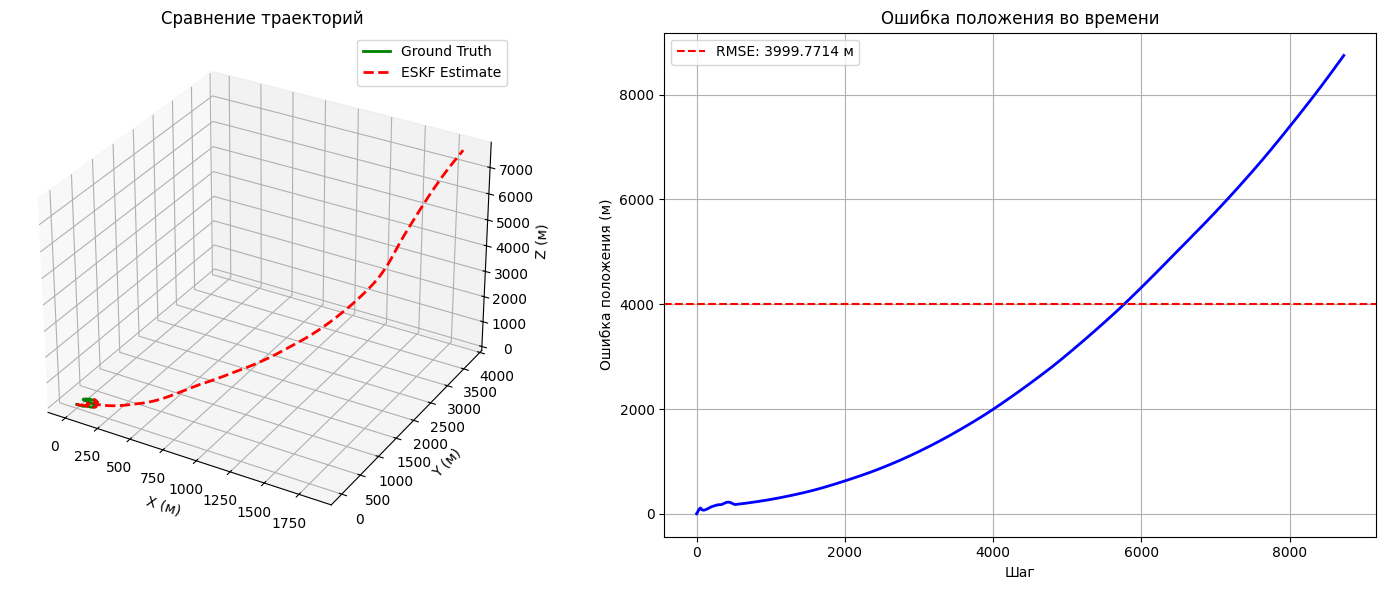


=== Результаты ===
RMSE положения: 3999.7714 м


In [6]:
print("Запуск ESKF фильтра...")
est_pos, rmse = run_eskf(
    data_path='data/data.pkl', 
    var_acc=0.01, var_gyro=0.02, 
    var_gnss=1.0, var_lidar=1.0, 
    P0_scale=1.0, eps=0.05, plot=True
)
print(f"\n=== Результаты ===")
print(f"RMSE положения: {rmse:.4f} м")